In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from evoscape.landscapes import CellDiff_Dataset_Landscape
from evoscape.modules import Node
import evoscape.landscape_visuals as vis
from evoscape.module_helper_functions import transform_coords, rotate_landscape, landscape_from_timecode, modules_from_txt
from evoscape.morphogen_regimes import mr_piecewise
from matplotlib.colors import ListedColormap, BoundaryNorm, CenteredNorm, Normalize
import cmcrameri.cm as cm

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from PIL import Image
import os

from matplotlib import style

colors = ('indianred', 'tab:orange', 'gold', 'tab:green', 'tab:blue', 'tab:purple')
cmap_state = ListedColormap(colors)
norm_state = BoundaryNorm(np.arange(len(colors)+1) - 0.5, cmap_state.N)

style.use('default')

In [44]:

plt.rcParams.update({'figure.dpi': 200})  # Change to 200 for high res figures
plt.rcParams.update({'font.size': 15})  
plt.rcParams['axes.grid'] = False


In [3]:
data_dir = '../alfyn_results_rev/saved_files_rev_1_delta3/CellDiff_Dataset_Landscape/'

data_dir = '../alfyn_results_stage2/saved_files_10/CellDiff_Dataset_Landscape/'


panels_dir = '../panels/'

file_name = data_dir + 'optimization_log.csv'


log = np.genfromtxt(file_name, delimiter='\t', skip_header=1, names=['Timecode', 'Init_timecode', 'Fitness'], dtype=None, encoding='utf-8')
print(log.shape)

# fitness threshold for selecting
n_landscapes = 60
fitness_threshold = np.partition(log['Fitness'], -n_landscapes)[-n_landscapes]
print(fitness_threshold)

timecodes = log['Timecode'][log['Fitness'] >= fitness_threshold]
fitnesses = log['Fitness'][log['Fitness'] >= fitness_threshold]
print(len(timecodes))

(239,)
-0.5686603997246658
60


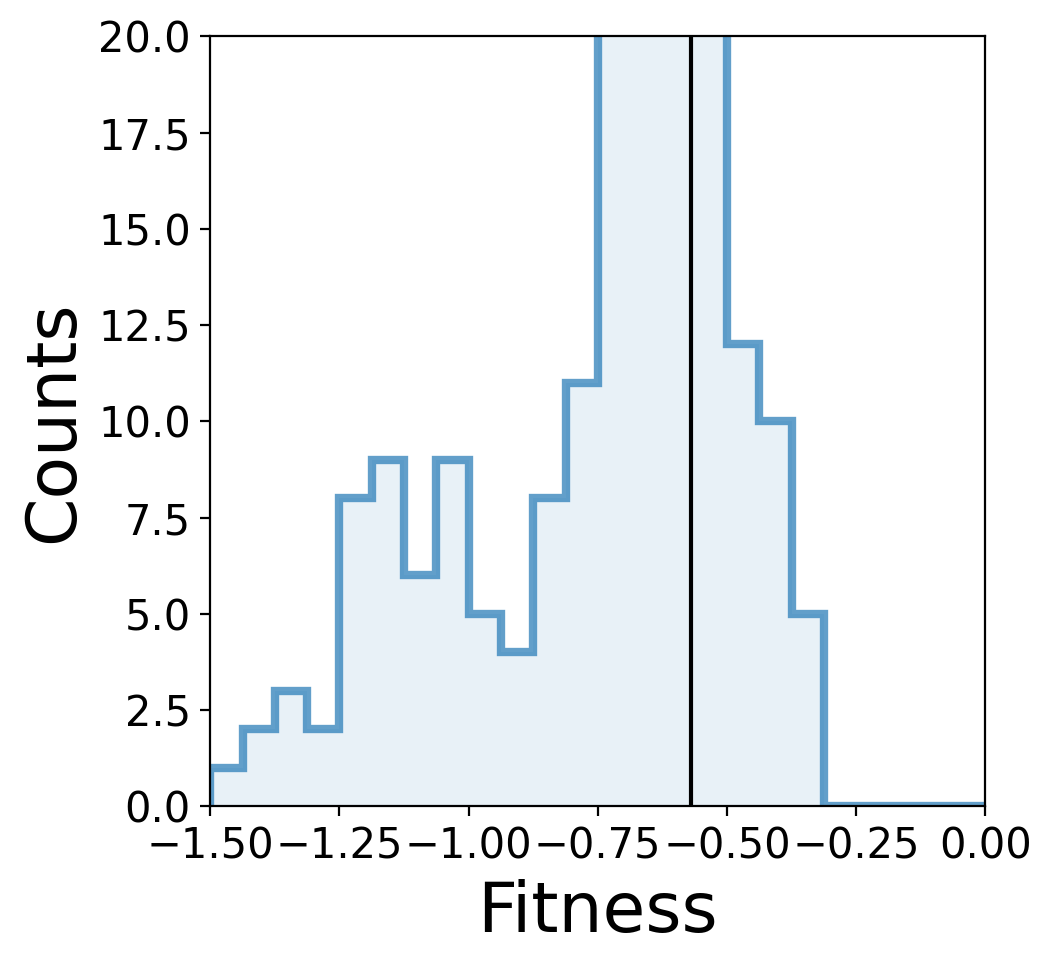

In [4]:
bins = np.linspace(-1.5, 0, 25)
plt.figure(figsize=(5,5))
plt.hist(log['Fitness'], bins=bins, density=False, alpha=0.1, histtype='stepfilled', lw=2, label='All')
plt.hist(log['Fitness'], bins=bins, density=False, alpha=0.7, histtype='step', linewidth=3, label='All', color='tab:blue')
plt.vlines(fitness_threshold, 0, 200, color='k')
plt.xlabel('Fitness', fontsize=25)
plt.ylabel('Counts', fontsize=25)
plt.ylim((0, 20))
plt.xlim((-1.5, 0))
plt.show()

In [6]:
def insert_sample_slide(pptx_path, data_dir, index, timecode):
    # Init presentation
    if not os.path.exists(pptx_path):
        prs = Presentation()
        prs.slide_width = Inches(16)
        prs.slide_height = Inches(9)
    else:
        prs = Presentation(pptx_path)

    slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank

    # Title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.2), Inches(15), Inches(0.5))
    text_frame = title_box.text_frame
    text_frame.text = f"{index:02d} — Timecode: {timecode}"
    p = text_frame.paragraphs[0]
    p.font.size = Pt(24)
    p.font.bold = False
    p.font.name = "Aptos"
    p.alignment = PP_ALIGN.LEFT
    p.font.color.rgb = RGBColor(0, 0, 0)

    # Layout constants
    margin_x = Inches(0.5)
    margin_y = Inches(0.8)
    spacing_x = Inches(0.2)
    spacing_y = Inches(0.1)
    fixed_height = Inches(2.7)  # consistent for all images

    # Row 1
    top_y1 = margin_y
    top_y2 = top_y1 + fixed_height - Inches(0.2)
    top_y3 = top_y2 + fixed_height

    idx = (1, 3, 2, 0, 4)
    loc = ((margin_x, top_y1), (margin_x+Inches(3), top_y1), (margin_x+Inches(6), top_y1),
           (margin_x, top_y2), (margin_x+Inches(3), top_y2))
    for i in range(5):
        filename = data_dir + timecode + '/result_landscape_' + str(idx[i]) +'.png'
        with Image.open(filename) as img:
            w, h = img.size
            left = w/3 + w*0.05
            right = 2*w/3
            cropped = img.crop((left, 0, right, h))

            temp_file = panels_dir + '/temp_cropped.png'
            cropped.save(temp_file)
        slide.shapes.add_picture(temp_file, *loc[i], height=fixed_height)

    idx = (1, 4)
    loc = ((margin_x, top_y3), (margin_x+Inches(5), top_y3),)
    for i in range(2):
        filename = data_dir + timecode + '/result_cell_trajectories_' + str(idx[i]) +'.png'
        slide.shapes.add_picture(filename, *loc[i], height=fixed_height)

    for j in range(7):
        filename = data_dir + timecode + '/result_proportions_' + str(j) + '.png'
        slide.shapes.add_picture(filename, Inches(12), margin_y+j*Inches(1.1), height=Inches(1.1))
    prs.save(pptx_path)

In [7]:

# for ind in range(60):
for ind in range(n_landscapes):
# for ind in (1,):
    timecode = timecodes[ind]
    insert_sample_slide(panels_dir+"Landscapes_regularized_2.pptx", data_dir, index=ind, timecode=str(timecode))


(300, 15)
(2, 300, 15)


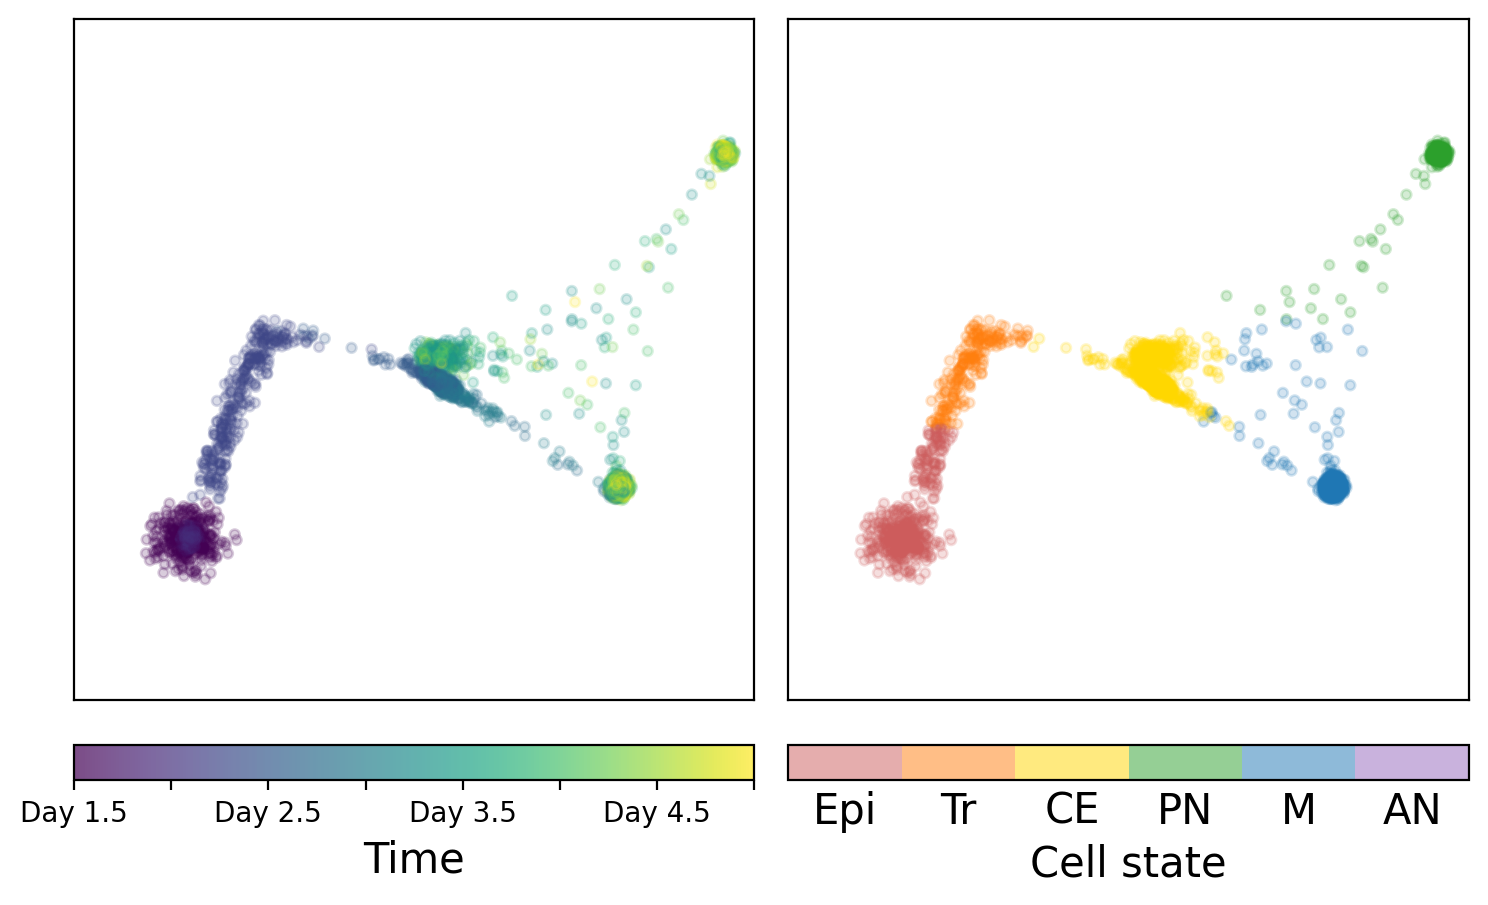

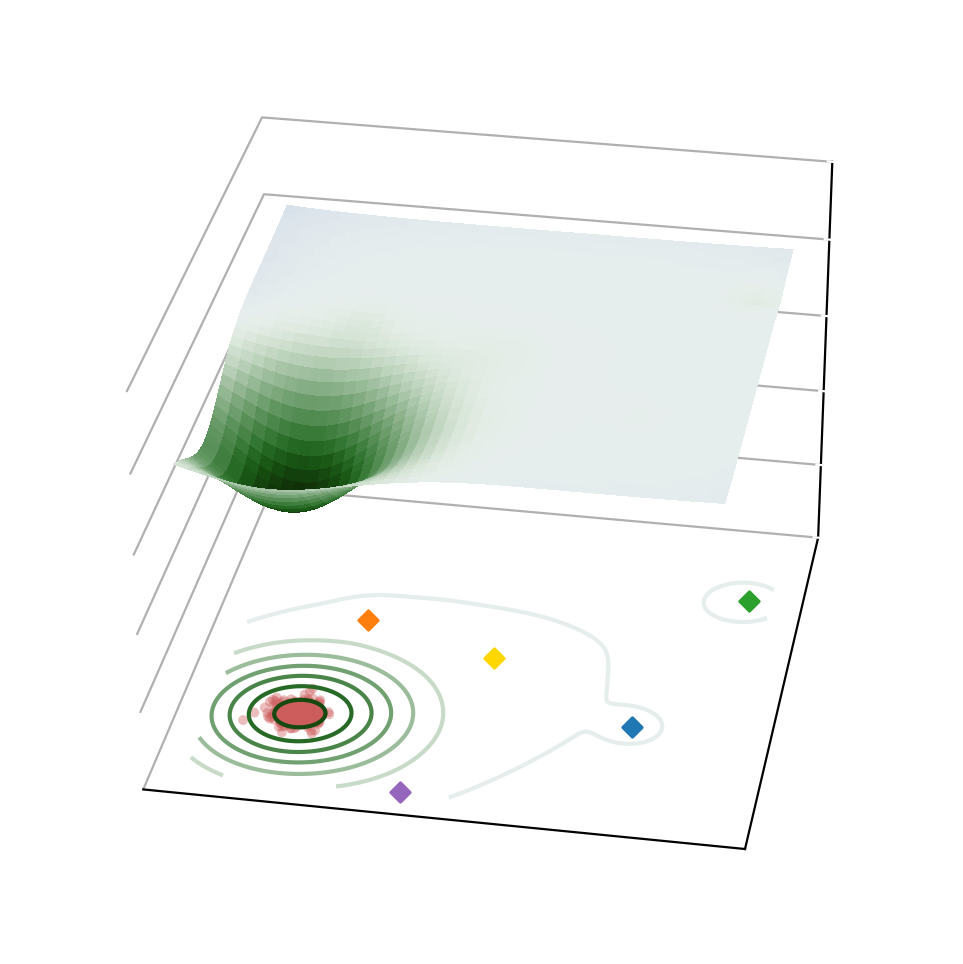

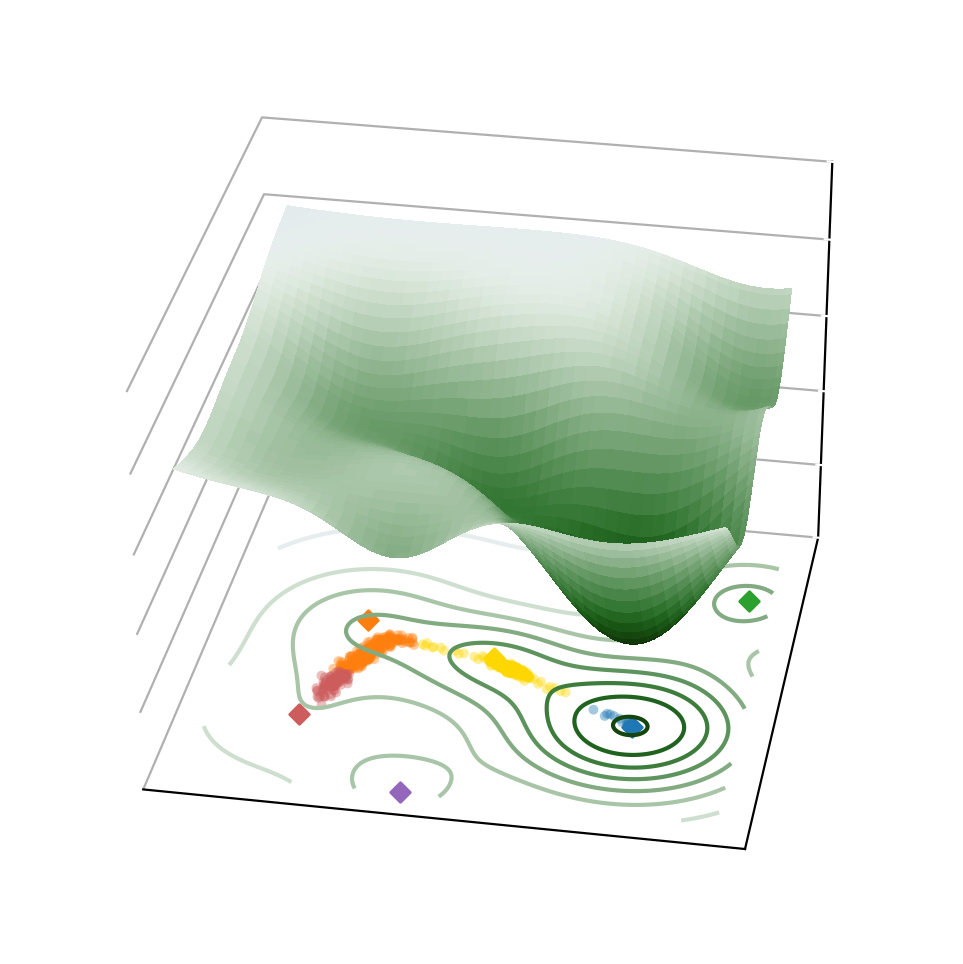

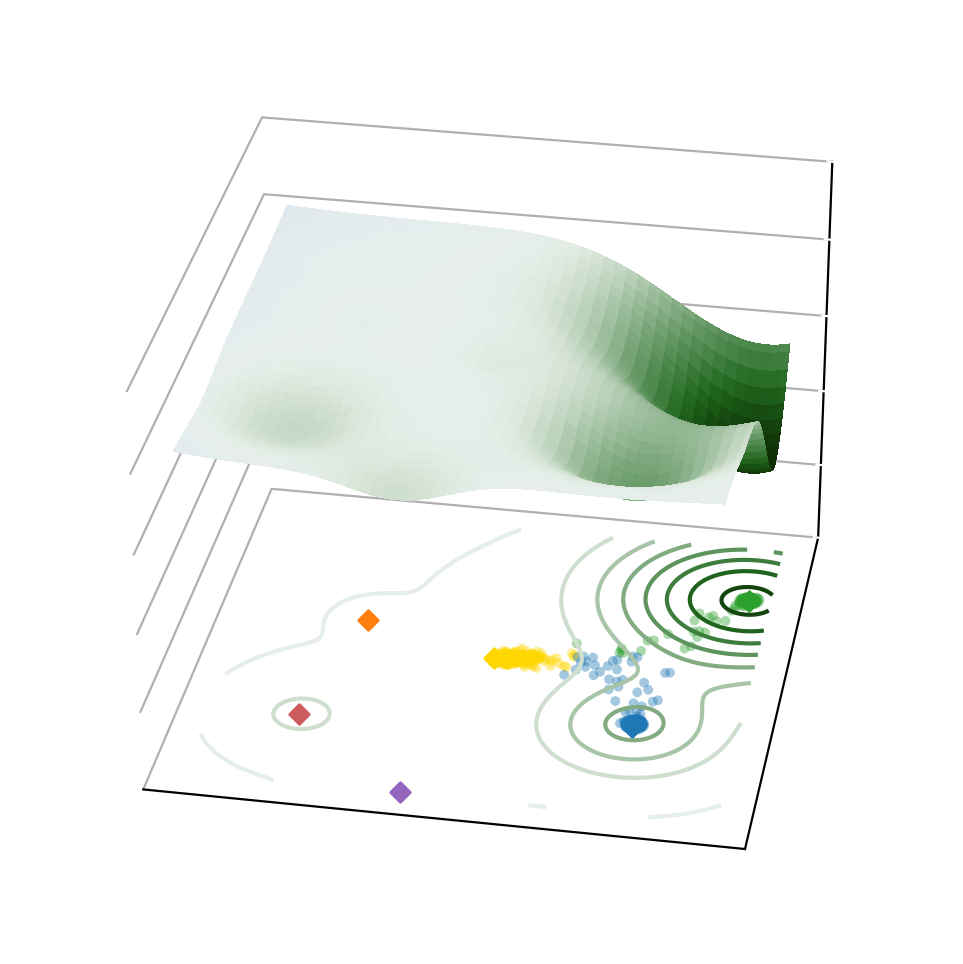

In [108]:
colors = ('indianred', 'tab:orange', 'gold', 'tab:green', 'tab:blue', 'tab:purple')
from scipy.interpolate import RegularGridInterpolator


timecode = '20250813-100034'
# timecode = '20250813-120236'

timecode = timecodes[48]

gen = 300

landscape_pars = {
    'A0': 0.005,
    'init_cond': (0., 0.),
    'regime': mr_piecewise,
    'n_regimes': 5,  # !
    'morphogen_times': None,
}

L = 4.
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q ,q, indexing = 'xy')  #!

origin = 2
direction = (3,4)
right = None   # !
bottom = 4
left = 0

delta=3.
noise = 0.2
ndt = 50
state_names = ('Epi', 'Tr', 'CE', 'PN', 'M', 'AN')

exp1 = (delta*3, delta*3, delta*3, delta*3)  # No Chir
exp2 = (delta*1, delta*3, delta*3, delta*3)   # Chir 2-3
exp5 = (delta*1, delta*3, delta*100, delta*100)  # Ch 2-5 FGF 0-3

time_pars = (0, delta*7, 15)
times = np.linspace(*time_pars)

landscape = landscape_from_timecode(CellDiff_Dataset_Landscape, timecode, data_dir, gen, landscape_pars)
landscape = rotate_landscape(landscape, origin=origin, direction=direction,
                             left=left, right=right, bottom=bottom)
landscape.morphogen_times = exp5


landscape.init_cells(300, 0, noise)
traj, states = landscape.run_cells(*time_pars, noise=noise)
print(states.shape)
print(traj.shape)
landscape.init_cells(300, 0, noise)
fig0 = vis.get_and_plot_traj(landscape, *time_pars, 4., noise, ndt = ndt, s=12, state_names=state_names,
                                t_ticks = (0, delta*7, 8),
                                t_names=('Day 1.5', '', 'Day 2.5', '', 'Day 3.5', '', 'Day 4.5', ''),)
                                # t_names=('', 'Day 2', '', 'Day 3', '', 'Day 4', '', 'Day 5'),)
ax = fig0.axes
ax[0].set_ylim((-4., 4))
ax[1].set_ylim((-4., 4))

regime_times = (times<delta*1, (times>delta*1)*(delta*3>times), times>delta*3,
                np.zeros(len(times)).astype('bool'), np.zeros(len(times)).astype('bool'))
t_r = (delta*0, delta*2, delta*4)

# print(regime_times)
for regime in range(3):
        fig = vis.visualize_potential(landscape, xx, yy, regime=regime, t=None, color_scheme='order', rot_contour=False, elev=30, azim=-80, cmap_center=0., offset=None, scatter=True, zlim=(-40, 10))
        _, pot, _ = landscape(t_r[regime], (xx, yy), return_potentials=True)
        ax = fig.get_axes()
        tr = traj[:,:, regime_times[regime]]
        c = states[:,regime_times[regime]]

        ax[0].scatter(tr[0, :], tr[1, :], -40, zorder=150, c=c, cmap=cmap_state, norm=norm_state, alpha=0.4, marker='.', lw=0, s=50)
        ax[0].set_xlim((-4.5,4.5))
        # ax[0].set_ylim((-5.,5.))


# for regime in range(5):
#     fig = vis.visualize_landscape(landscape, xx, yy, regime=regime, color_scheme='order', circles=False)
#     ax = fig.axes[0]
#     for im, module in enumerate(landscape.module_list):
#             ax.scatter(module.x, module.y, c=colors[im], marker='D', s=150, edgecolor='None', alpha=0.6, zorder=15)
#     plt.show()